In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load CSV
labels = pd.read_csv("/content/labels.csv")

# Show first rows
print(labels.head())

# Show columns
print("\nColumns:")
print(labels.columns)

                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal

Columns:
Index(['filename', 'class'], dtype='object')


# Task 1: Problem Identification

# Selected Problem Type:

This dataset represents an image classification problem.

Explanation:

This dataset contains images of manufacturing product surfaces categorized into four classes:

normal
scratch
dent
stain

Each image is assigned a single label representing the type of defect present on the product surface. The objective is to train a CNN model that can classify an input image into one of these predefined categories.


Why Other Problem Types Are Not Suitable:

# Object Detection:
The dataset does not contain bounding boxes to locate defects.
# Semantic Segmentation:
The dataset does not contain pixel-wise masks.

# Instance Segmentation:
The dataset does not contain separate instance masks for defects.

# Conclusion:

Thus we can say that, The dataset represents an image classification problem because each image is assigned a single class label, and the goal is to classify the entire image into one category.

In [2]:
df = pd.read_csv("labels.csv")

df.head()

# Number of classes
num_classes = df["class"].nunique()

print("\n Number of classes:", num_classes)
print("\n Classes:", df["class"].unique())

# Number of Images per class
class_counts = df["class"].value_counts()

print(class_counts)

print("\n Total images:", len(df))




 Number of classes: 4

 Classes: ['normal' 'scratch' 'dent' 'stain']
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64

 Total images: 480


                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal
Index(['filename', 'class'], dtype='object')
Trying to open: /content/part_2_cnn_computer_vision/part_2_cnn_computer_vision/images/normal/normal_001.png
Sample Image Dimension for normal: (96, 96)
Trying to open: /content/part_2_cnn_computer_vision/part_2_cnn_computer_vision/images/scratch/scratch_001.png
Sample Image Dimension for scratch: (96, 96)
Trying to open: /content/part_2_cnn_computer_vision/part_2_cnn_computer_vision/images/dent/dent_001.png
Sample Image Dimension for dent: (96, 96)
Trying to open: /content/part_2_cnn_computer_vision/part_2_cnn_computer_vision/images/stain/stain_001.png
Sample Image Dimension for stain: (96, 96)


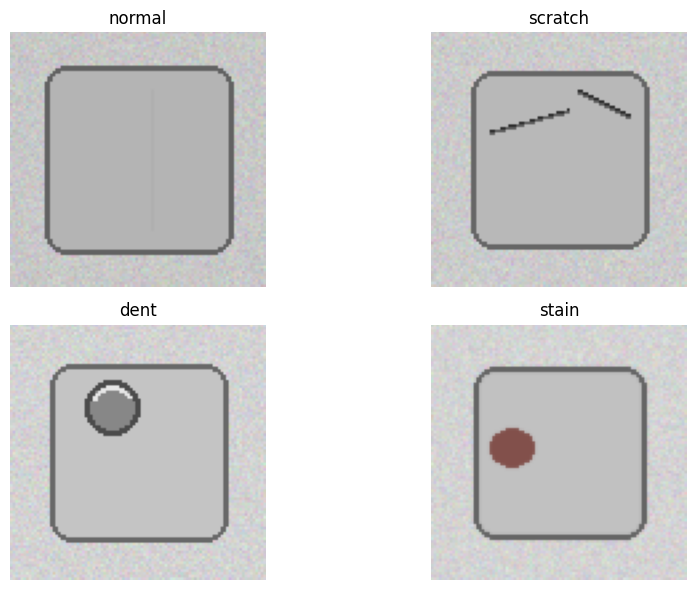

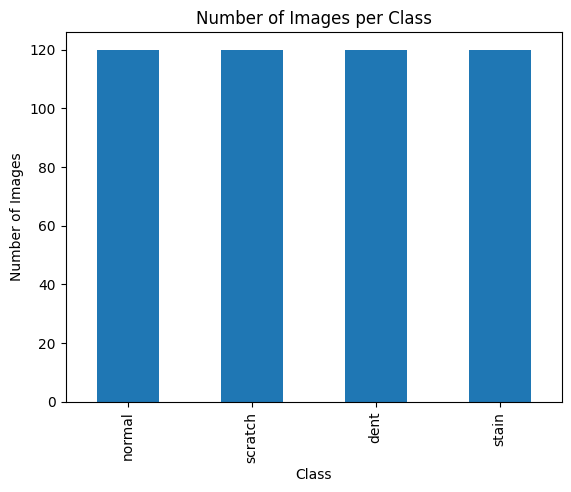

In [15]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ZIP file path
zip_path = "/content/part_2_cnn_computer_vision.zip"

# Extraction folder
extract_path = "/content/part_2_cnn_computer_vision"

# Unzip the file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Correct dataset folder path
dataset_folder = "/content/part_2_cnn_computer_vision/part_2_cnn_computer_vision"

# Correct labels.csv path
labels_path = os.path.join(dataset_folder, "labels.csv")

# Load labels.csv
df = pd.read_csv(labels_path)

print(df.head())
print(df.columns)

classes = df["class"].unique()

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):

    # Get first image path from CSV
    relative_path = df[df["class"] == cls]["filename"].iloc[0]

    # Full image path
    img_path = os.path.join(dataset_folder, relative_path)

    print("Trying to open:", img_path)

    if os.path.exists(img_path):
        img = Image.open(img_path)

        print(f"Sample Image Dimension for {cls}: {img.size}")

        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    else:
        print("Image not found:", img_path)

plt.tight_layout()
plt.show()

# Dataset imbalance analysis

class_counts.plot(kind="bar")

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()



The labels.csv file contains image filenames and class labels.
The dataset has 4 classes:
normal, scratch, dent, and stain.
Each class contains 120 images, so the dataset is *balanced* .


In [17]:
# List to store image dimensions
image_dimensions = []

# Loop through all image paths
for img_file in df["filename"]:

    # Create full image path
    img_path = os.path.join(dataset_folder, img_file)

    # Check whether image exists
    if os.path.exists(img_path):

        # Open image
        img = Image.open(img_path)

        # Store width and height
        image_dimensions.append(img.size)

    else:
        print("Image not found:", img_path)

# Show first 10 image dimensions
print("First 10 image dimensions:")
print(image_dimensions[:10])

# Show unique image dimensions
unique_dimensions = set(image_dimensions)

print("\nUnique image dimensions:")
print(unique_dimensions)

# Total unique dimensions
print("\nNumber of unique image dimensions:", len(unique_dimensions))

First 10 image dimensions:
[(96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96)]

Unique image dimensions:
{(96, 96)}

Number of unique image dimensions: 1


In [18]:
# Task 3: Image Preprocessing

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_folder = "/content/part_2_cnn_computer_vision/part_2_cnn_computer_vision"

labels_path = os.path.join(dataset_folder, "labels.csv")

# Load labels file
df = pd.read_csv(labels_path)

# Create full image path
df["full_path"] = df["filename"].apply(lambda x: os.path.join(dataset_folder, x))

# Check image files
df["file_exists"] = df["full_path"].apply(os.path.exists)

print("File exists check:")
print(df["file_exists"].value_counts())

# Keep only existing images
df = df[df["file_exists"] == True]

# Image settings
image_size = (128, 128)
batch_size = 32

# Split into train and test data
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["class"]
)

print("\nTraining images:", len(train_df))
print("Testing images:", len(test_df))

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Testing generator without augmentation
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Create training data
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="full_path",
    y_col="class",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

# Create testing data
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="full_path",
    y_col="class",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Show class labels
print("\nClass labels:")
print(train_generator.class_indices)


File exists check:
file_exists
True    480
Name: count, dtype: int64

Training images: 384
Testing images: 96
Found 384 validated image filenames belonging to 4 classes.
Found 96 validated image filenames belonging to 4 classes.

Class labels:
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


Note: The images were preprocessed before model training.

*  First, the image paths were created using the filenames given in labels.csv.

*   All images were resized to a fixed size of 128 × 128 pixels so that they have the same input shape.
Pixel values were normalized by dividing by 255, which converts the range from 0–255 to 0–1.

*  The dataset was split into training and testing sets using an 80:20 ratio, while maintaining the same class distribution using stratified splitting.

*   Image augmentation was applied to the training data using rotation, zooming, and horizontal flipping to improve model generalization.

*  The testing data was only normalized and not augmented.

In [19]:
# Task 4: CNN Model Creation

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Number of output classes
num_classes = len(train_generator.class_indices)

print("Number of classes:", num_classes)

# Create CNN model
model = Sequential()

# Convolution layer + Activation function
model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    input_shape=(128, 128, 3)
))

# Pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolution layer + Activation function
model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation='relu'
))

# Second pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten layer
model.add(Flatten())

# Dense layer
model.add(Dense(128, activation='relu'))

# Dropout layer
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model structure
model.summary()

Number of classes: 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Note: A Convolutional Neural Network was built for image classification.

*  The model includes convolution layers to extract image features, ReLU activation functions to learn non-linear patterns, pooling layers to reduce image size and computation, a flatten layer to convert image features into a one-dimensional vector, and dense layers for classification.

*  Since the dataset has 4 classes, the output layer
contains 4 neurons with the softmax activation function.

*  The model was compiled using the Adam optimizer and categorical cross-entropy loss function, which is suitable for multi-class image classification.

Training CNN Model
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2188 - loss: 4.3602 - val_accuracy: 0.2500 - val_loss: 1.3890
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2708 - loss: 1.3884 - val_accuracy: 0.6146 - val_loss: 1.3817
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 998ms/step - accuracy: 0.3698 - loss: 1.3691 - val_accuracy: 0.6875 - val_loss: 1.3219
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.4479 - loss: 1.2842 - val_accuracy: 0.4583 - val_loss: 1.1778
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 932ms/step - accuracy: 0.5391 - loss: 1.1391 - val_accuracy: 0.7500 - val_loss: 0.9999
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 863ms/step - accuracy: 0.5859 - loss: 0.9709 - val_accuracy: 0.7500 - val_loss: 0.7080
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 960ms/step - accuracy: 0.7240 - loss: 0.7352 - val_accuracy: 0.7917 - val_loss: 0.6238
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 977ms/step - accuracy: 0.7448 - loss: 0.6762 

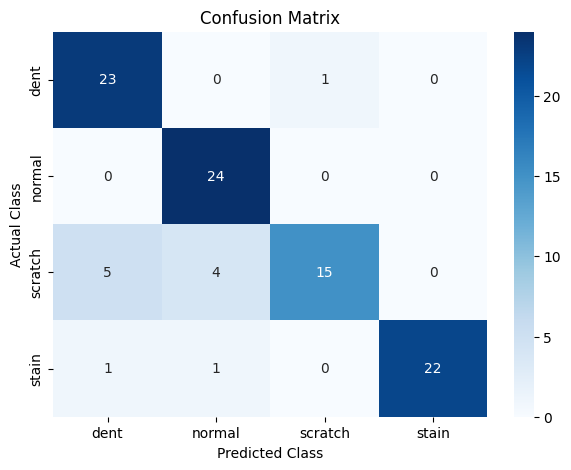


Classification Report
              precision    recall  f1-score   support

        dent       0.79      0.96      0.87        24
      normal       0.83      1.00      0.91        24
     scratch       0.94      0.62      0.75        24
       stain       1.00      0.92      0.96        24

    accuracy                           0.88        96
   macro avg       0.89      0.88      0.87        96
weighted avg       0.89      0.88      0.87        96



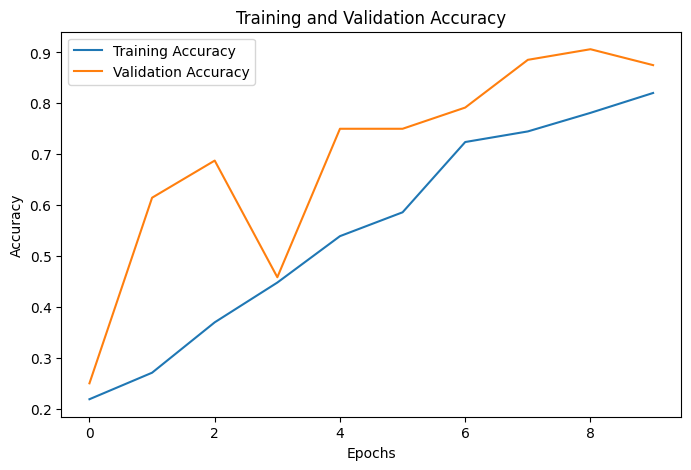

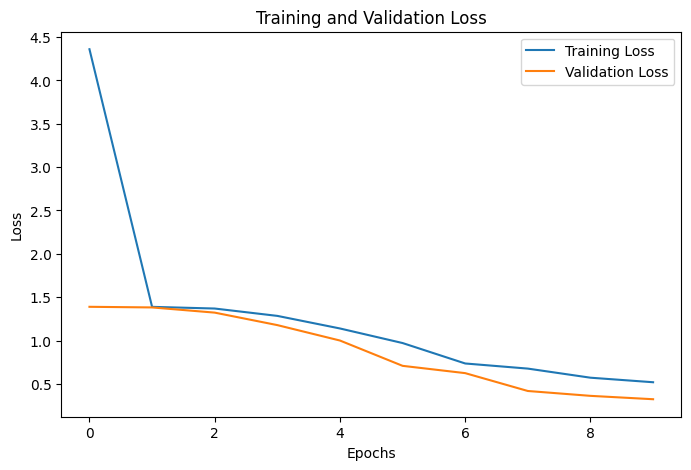

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


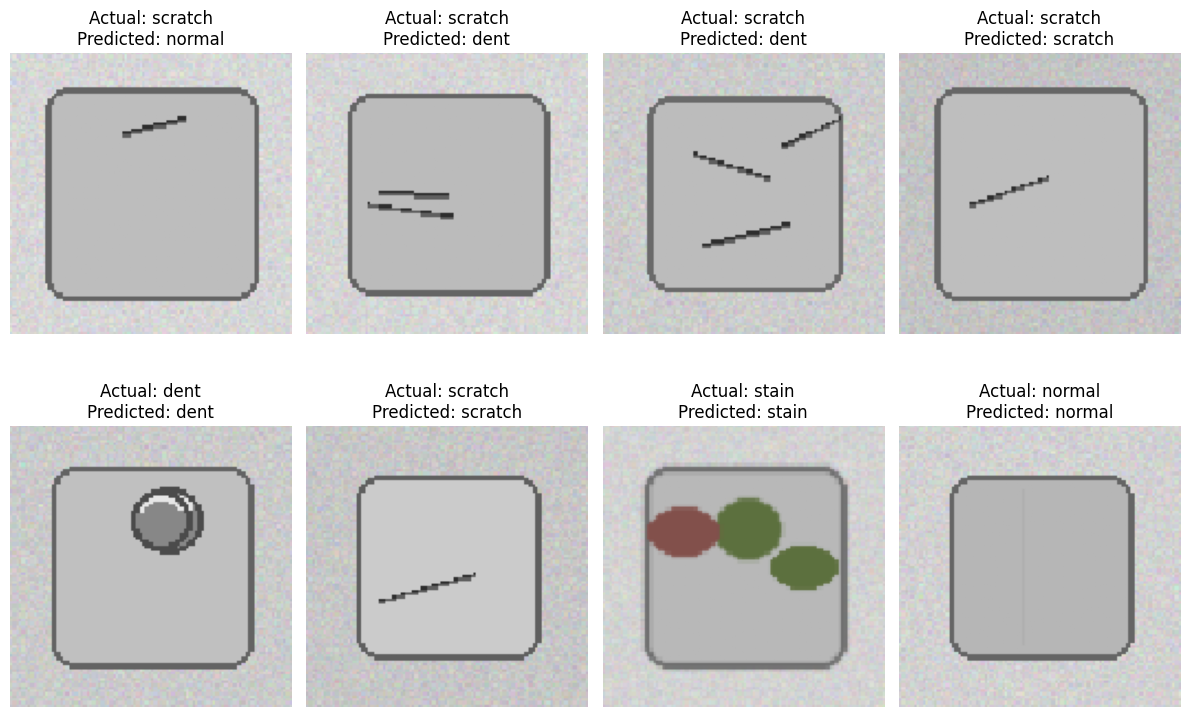

In [20]:
# Task 5: Model Training and Evaluation

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# TRAIN THE CNN MODEL

print("Training CNN Model")

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

# TRAINING AND VALIDATION PERFORMANCE

train_accuracy = history.history["accuracy"][-1]
train_loss = history.history["loss"][-1]

val_accuracy = history.history["val_accuracy"][-1]
val_loss = history.history["val_loss"][-1]

print("\nTraining Accuracy:", round(train_accuracy * 100, 2), "%")
print("Training Loss:", round(train_loss, 4))

print("\nValidation Accuracy:", round(val_accuracy * 100, 2), "%")
print("Validation Loss:", round(val_loss, 4))


# TESTING PERFORMANCE

test_loss, test_accuracy = model.evaluate(test_generator)

print("\nTesting Accuracy:", round(test_accuracy * 100, 2), "%")
print("Testing Loss:", round(test_loss, 4))

# PREDICTIONS

y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# CLASSIFICATION REPORT

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

# ACCURACY GRAPH

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

# LOSS GRAPH

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

# SAMPLE PREDICTIONS ON TEST IMAGES

# Reset test generator before taking sample images
test_generator.reset()

# Get one batch of test images
images, labels = next(test_generator)

# Predict on sample images
predictions = model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])

    actual_label = class_names[actual_classes[i]]
    predicted_label = class_names[predicted_classes[i]]

    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Task 6: CNN Concept Explanation

* What is Convolution?
Convolution is a mathematical operation used in CNNs to extract important features from images such as edges, textures, patterns, and shapes. Small filters (kernels) move across the image and detect useful visual information. This helps the CNN understand image patterns automatically.

* Why is Pooling Used?

Pooling is used to reduce the size of feature maps generated by convolution layers. It helps:

reduce computation
reduce memory usage
prevent overfitting
make feature detection more robust
Max Pooling is commonly used because it keeps the most important features from an image.

*  Why is ReLU Commonly Used in CNNs?

ReLU (Rectified Linear Unit) is an activation function defined as:

:contentReference[oaicite:0]{index=0}

It converts negative values to zero and keeps positive values unchanged.

ReLU is commonly used because:

it makes training faster
reduces vanishing gradient problems
improves model performance
introduces non-linearity into the network

*   Why are CNNs Better than Regular Feed-Forward Networks for Image Data?

CNNs are better for image data because they automatically learn spatial features such as edges, textures, and shapes directly from images.

Advantages of CNNs:

fewer parameters compared to fully connected networks
automatic feature extraction
better accuracy for image tasks
efficient handling of large image datasets
Regular feed-forward neural networks cannot efficiently preserve spatial relationships between image pixels, while CNNs are specifically designed for image processing tasks.